In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(".data/bot_detection_data.csv")
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   User ID         50000 non-null  int64
 1   Username        50000 non-null  str  
 2   Tweet           50000 non-null  str  
 3   Retweet Count   50000 non-null  int64
 4   Mention Count   50000 non-null  int64
 5   Follower Count  50000 non-null  int64
 6   Verified        50000 non-null  bool 
 7   Bot Label       50000 non-null  int64
 8   Location        50000 non-null  str  
 9   Created At      50000 non-null  str  
 10  Hashtags        41659 non-null  str  
dtypes: bool(1), int64(5), str(5)
memory usage: 3.9 MB


,User ID,Username,Tweet,Retweet Count,Mention Count,Follower Count,Verified,Bot Label,Location,Created At,Hashtags
0,132131,flong,Station activity person against natural majori...,85,1,2353,False,1,Adkinston,2020-05-11 15:29:50,NaN
1,289683,hinesstephanie,Authority research natural life material staff...,55,5,9617,True,0,Sanderston,2022-11-26 05:18:10,both live
2,779715,roberttran,Manage whose quickly especially foot none to g...,6,2,4363,True,0,Harrisonfurt,2022-08-08 03:16:54,phone ahead
3,696168,pmason,Just cover eight opportunity strong policy which.,54,5,2242,True,1,Martinezberg,2021-08-14 22:27:05,ever quickly new I
4,704441,noah87,Animal sign six data good or.,26,3,8438,False,1,Camachoville,2020-04-13 21:24:21,foreign mention


Shape: (50000, 11)

Columns and dtypes:
 User ID                    int64
Username                     str
Tweet                        str
Retweet Count              int64
Mention Count              int64
Follower Count             int64
Verified                    bool
Bot Label                  int64
Location                     str
Created At        datetime64[us]
Hashtags                     str
dtype: object

Missing values:
 User ID              0
Username             0
Tweet                0
Retweet Count        0
Mention Count        0
Follower Count       0
Verified             0
Bot Label            0
Location             0
Created At           0
Hashtags          8341
dtype: int64

Unique counts (selected):
  User IDs: 50000
  Usernames: 40566
  Locations: 25199
  Hashtags (non-null): 41659

Numeric summary:
                   count        mean          std  min      25%     50%  \
Retweet Count   50000.0    50.00560    29.181160  0.0    25.00    50.0   
Mention Count   500

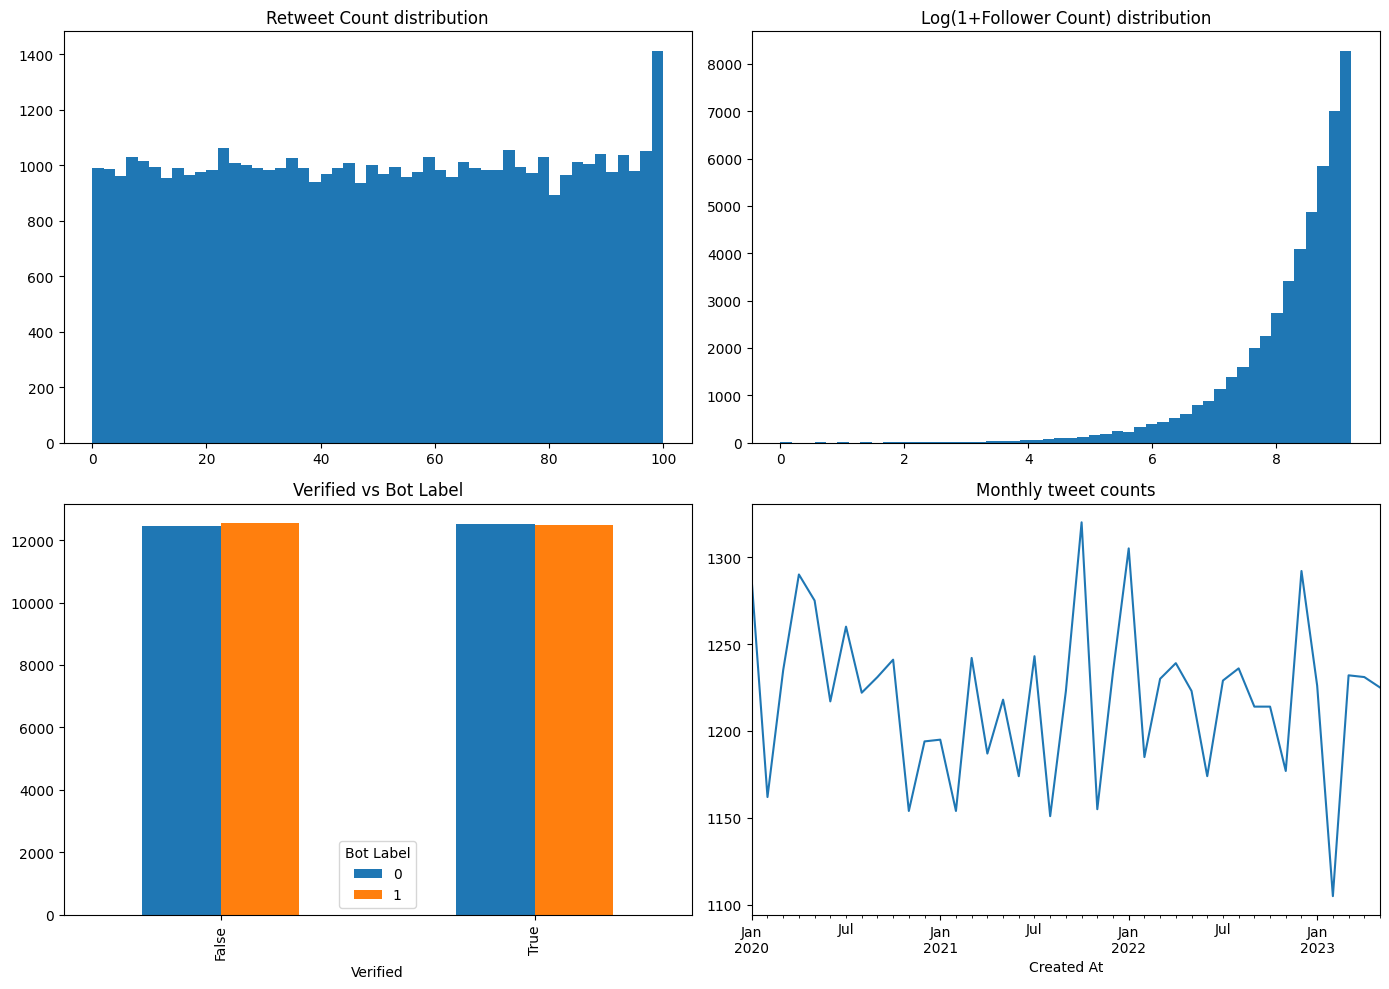

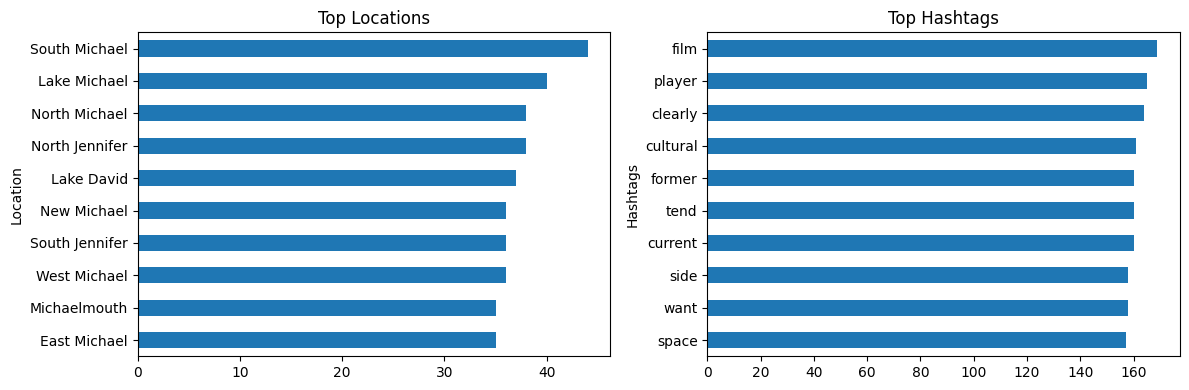

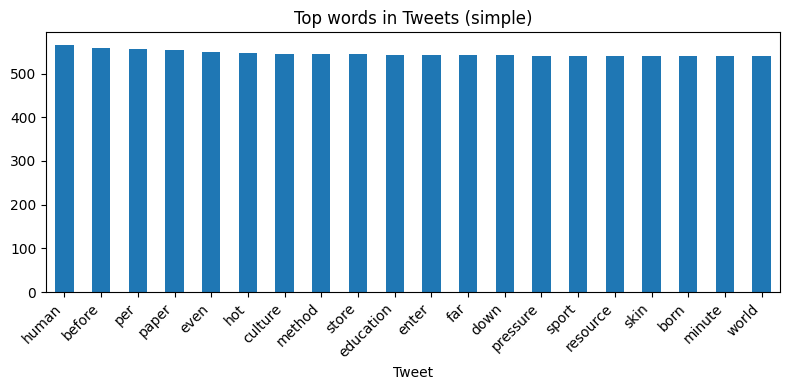

{'shape': (50000, 11),
 'dtypes': User ID                    int64
 Username                     str
 Tweet                        str
 Retweet Count              int64
 Mention Count              int64
 Follower Count             int64
 Verified                    bool
 Bot Label                  int64
 Location                     str
 Created At        datetime64[us]
 Hashtags                     str
 dtype: object,
 'missing': User ID              0
 Username             0
 Tweet                0
 Retweet Count        0
 Mention Count        0
 Follower Count       0
 Verified             0
 Bot Label            0
 Location             0
 Created At           0
 Hashtags          8341
 dtype: int64,
 'numeric_summary':                   count        mean          std  min      25%     50%  \
 Retweet Count   50000.0    50.00560    29.181160  0.0    25.00    50.0   
 Mention Count   50000.0     2.51376     1.708563  0.0     1.00     3.0   
 Follower Count  50000.0  4988.60238  2878.

In [10]:
import re

# Quick EDA summary and plots for df

# Basic overview
print("Shape:", df.shape)
print("\nColumns and dtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nUnique counts (selected):")
print("  User IDs:", df['User ID'].nunique())
print("  Usernames:", df['Username'].nunique())
print("  Locations:", df['Location'].nunique())
print("  Hashtags (non-null):", df['Hashtags'].notna().sum())

# Descriptive statistics
print("\nNumeric summary:\n", df[['Retweet Count', 'Mention Count', 'Follower Count']].describe().T)
print("\nCategorical summary (top values):")
print("Verified:\n", df['Verified'].value_counts(dropna=False))
print("Bot Label:\n", df['Bot Label'].value_counts(dropna=False))

# Ensure datetime
df['Created At'] = pd.to_datetime(df['Created At'], errors='coerce')

# Time-based counts
time_counts = df.set_index('Created At').resample('ME').size()

# Top locations and hashtags
top_locations = df['Location'].fillna("Unknown").value_counts().head(10)
top_hashtags = (df['Hashtags'].dropna()
                    .str.split()
                    .explode()
                    .value_counts()
                    .head(10))

# Top words from tweets (simple tokenization, small stoplist)
stopwords = {"the","and","a","to","of","in","is","for","on","that","it","this","with","as","are","was","be","have","but","or","by","an","at"}
tweets_text = df['Tweet'].dropna().str.lower()
words = tweets_text.str.findall(r"\b[a-z]{2,}\b").explode()
words = words[~words.isin(stopwords)]
top_words = words.value_counts().head(20)

# Plots
plt.figure(figsize=(14,10))

plt.subplot(2,2,1)
plt.hist(df['Retweet Count'].dropna(), bins=50)
plt.title('Retweet Count distribution')

plt.subplot(2,2,2)
plt.hist(np.log1p(df['Follower Count'].dropna()), bins=50)
plt.title('Log(1+Follower Count) distribution')

plt.subplot(2,2,3)
pd.crosstab(df['Verified'], df['Bot Label']).plot(kind='bar', stacked=False, ax=plt.gca())
plt.title('Verified vs Bot Label')

plt.subplot(2,2,4)
time_counts.plot(ax=plt.gca())
plt.title('Monthly tweet counts')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
top_locations.plot(kind='barh')
plt.title('Top Locations')
plt.gca().invert_yaxis()

plt.subplot(1,2,2)
top_hashtags.plot(kind='barh')
plt.title('Top Hashtags')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
top_words.plot(kind='bar')
plt.title('Top words in Tweets (simple)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Return summary objects for further inspection if needed
eda_summary = {
    "shape": df.shape,
    "dtypes": df.dtypes,
    "missing": df.isnull().sum(),
    "numeric_summary": df[['Retweet Count', 'Mention Count', 'Follower Count']].describe().T,
    "verified_counts": df['Verified'].value_counts(dropna=False),
    "bot_label_counts": df['Bot Label'].value_counts(dropna=False),
    "monthly_counts": time_counts,
    "top_locations": top_locations,
    "top_hashtags": top_hashtags,
    "top_words": top_words
}
eda_summary

ANÁLISIS COMPARATIVO: BOTS vs NO-BOTS

1. ESTADÍSTICAS DESCRIPTIVAS POR GRUPO

--- Verified ---
           count unique    top   freq
Bot Label                            
0          24982      2   True  12526
1          25018      2  False  12540

--- Follower Count ---
             count         mean          std  min      25%     50%     75%  \
Bot Label                                                                    
0          24982.0  4985.255664  2881.251104  0.0  2480.25  5007.5  7472.0   
1          25018.0  4991.944280  2876.289818  0.0  2497.00  4978.0  7468.0   

               max  
Bot Label           
0          10000.0  
1          10000.0  

  T-test p-value: 0.795044 ns

--- Retweet Count ---
             count       mean        std  min   25%   50%   75%    max
Bot Label                                                             
0          24982.0  49.969098  29.191822  0.0  25.0  50.0  75.0  100.0
1          25018.0  50.042050  29.171048  0.0  25.0  50.0  75.0 

C:\Users\jrtor\AppData\Local\Temp\ipykernel_21732\3502273704.py:120: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(retweet_data, labels=['No-Bot', 'Bot'])
C:\Users\jrtor\AppData\Local\Temp\ipykernel_21732\3502273704.py:128: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot(mention_data, labels=['No-Bot', 'Bot'])


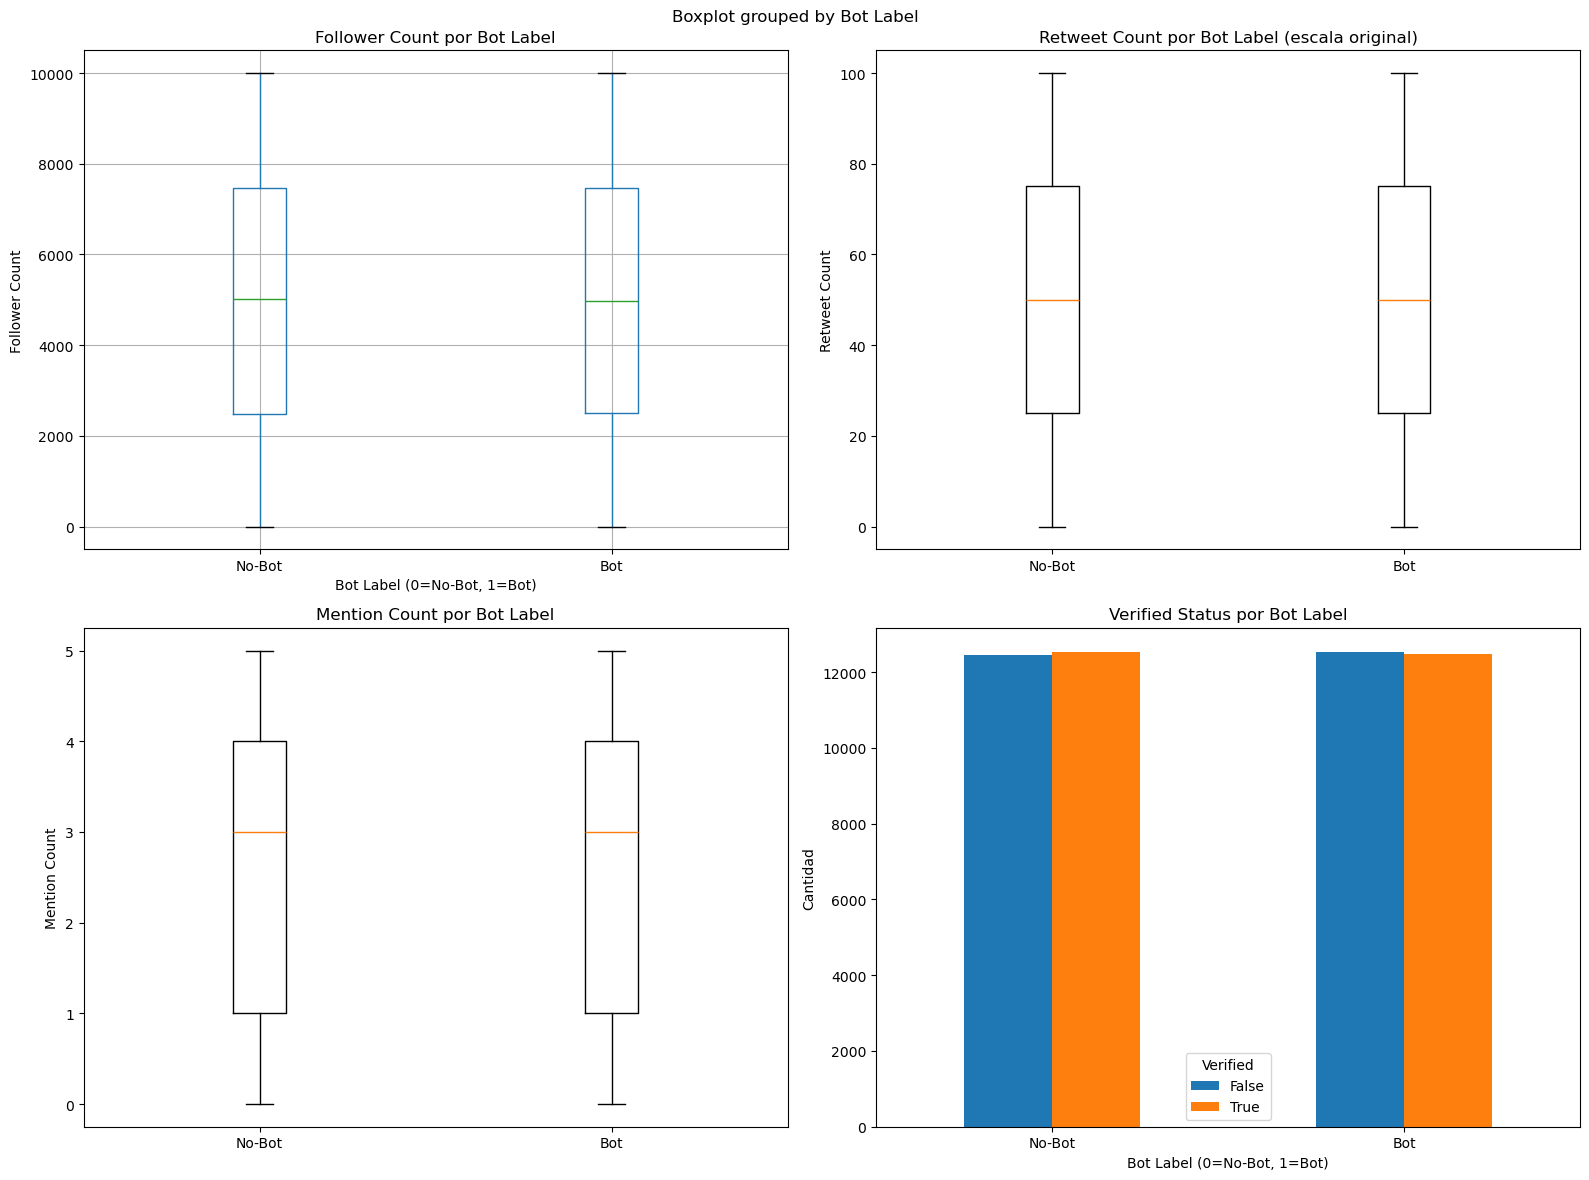

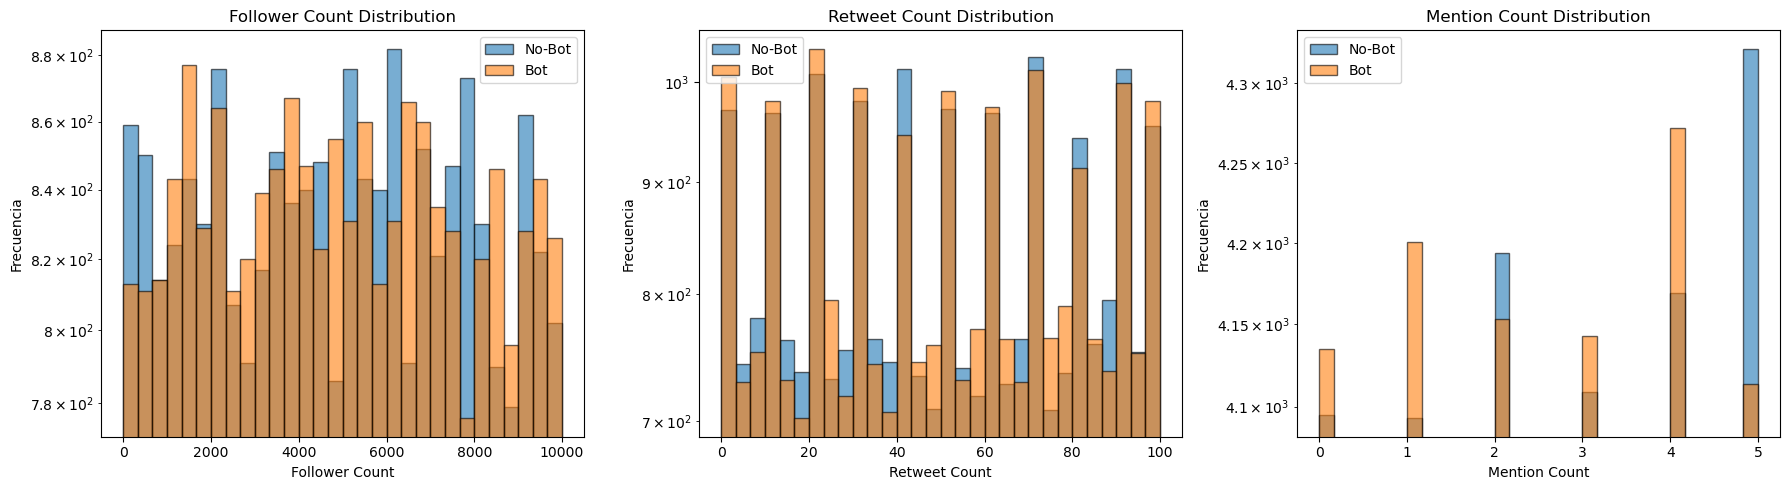

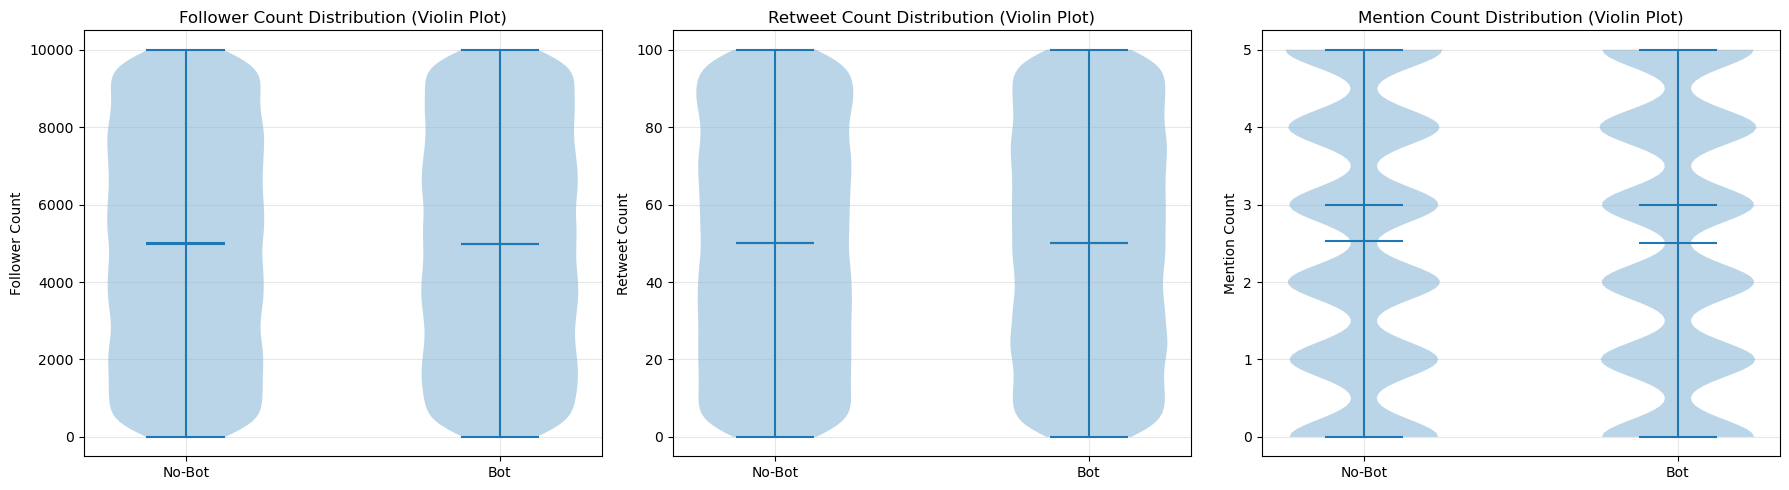


✓ Análisis completado


In [3]:
import seaborn as sns
from scipy import stats

# Convertir Created At a datetime
df['Created At'] = pd.to_datetime(df['Created At'], errors='coerce')

# ============================================================================
# COMPARACIÓN DE FEATURES ENTRE BOTS Y NO-BOTS
# ============================================================================

print("="*80)
print("ANÁLISIS COMPARATIVO: BOTS vs NO-BOTS")
print("="*80)

# Variables de interés
features = ['Verified', 'Follower Count', 'Retweet Count', 'Mention Count']

# 1. ESTADÍSTICAS DESCRIPTIVAS POR BOT LABEL
print("\n" + "="*80)
print("1. ESTADÍSTICAS DESCRIPTIVAS POR GRUPO")
print("="*80)

for feature in features:
    print(f"\n--- {feature} ---")
    grouped = df.groupby('Bot Label')[feature].describe()
    print(grouped)
    
    # T-test para variables numéricas (no Verified)
    if feature != 'Verified':
        bots = df[df['Bot Label'] == 1][feature].dropna()
        non_bots = df[df['Bot Label'] == 0][feature].dropna()
        
        if len(bots) > 0 and len(non_bots) > 0:
            t_stat, p_value = stats.ttest_ind(bots, non_bots)
            print(f"\n  T-test p-value: {p_value:.6f} {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'}")

# 2. ANÁLISIS ESPECÍFICO DE VERIFIED
print("\n" + "="*80)
print("2. ANÁLISIS DE VERIFIED (Booleano)")
print("="*80)

verified_crosstab = pd.crosstab(df['Bot Label'], df['Verified'], margins=True)
print("\nCrosstab (Bot Label vs Verified):")
print(verified_crosstab)

# Porcentajes
verified_pct = pd.crosstab(df['Bot Label'], df['Verified'], normalize='index') * 100
print("\nPorcentajes por grupo:")
print(verified_pct.round(2))

# 3. ANÁLISIS DE OUTLIERS (IQR method)
print("\n" + "="*80)
print("3. DETECCIÓN DE OUTLIERS (IQR method)")
print("="*80)

for feature in ['Follower Count', 'Retweet Count', 'Mention Count']:
    print(f"\n--- {feature} ---")
    for bot_label in [0, 1]:
        label_name = "BOT" if bot_label == 1 else "NO-BOT"
        data = df[df['Bot Label'] == bot_label][feature].dropna()
        
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = data[(data < lower_bound) | (data > upper_bound)]
        
        print(f"\n  {label_name}:")
        print(f"    Q1={Q1:.0f}, Q3={Q3:.0f}, IQR={IQR:.0f}")
        print(f"    Límites: [{lower_bound:.0f}, {upper_bound:.0f}]")
        print(f"    Outliers: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")
        if len(outliers) > 0:
            print(f"    Rango outliers: [{outliers.min():.0f}, {outliers.max():.0f}]")

# 4. ANÁLISIS DE CREATED_AT (Datos faltantes)
print("\n" + "="*80)
print("4. ANÁLISIS DE CREATED_AT")
print("="*80)

print(f"\nTotal de registros: {len(df)}")
print(f"Created At no-nulos: {df['Created At'].notna().sum()}")
print(f"Created At nulos: {df['Created At'].isna().sum()} ({df['Created At'].isna().sum()/len(df)*100:.1f}%)")

# Datos nulos por bot label
print("\nDatos nulos en Created At por grupo:")
missing_by_label = df.groupby('Bot Label')['Created At'].apply(lambda x: (x.isna().sum(), len(x)))
print(f"  NO-BOT: {missing_by_label[0][0]}/{missing_by_label[0][1]} ({missing_by_label[0][0]/missing_by_label[0][1]*100:.1f}%)")
print(f"  BOT: {missing_by_label[1][0]}/{missing_by_label[1][1]} ({missing_by_label[1][0]/missing_by_label[1][1]*100:.1f}%)")

# Rango de fechas válidas
valid_dates = df['Created At'].dropna()
if len(valid_dates) > 0:
    print(f"\nRango de fechas válidas:")
    print(f"  Más antigua: {valid_dates.min()}")
    print(f"  Más reciente: {valid_dates.max()}")
    print(f"  Span: {(valid_dates.max() - valid_dates.min()).days} días")

# 5. VISUALIZACIONES COMPARATIVAS
print("\n" + "="*80)
print("5. GENERANDO VISUALIZACIONES...")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Boxplot: Follower Count
ax1 = axes[0, 0]
df.boxplot(column='Follower Count', by='Bot Label', ax=ax1)
ax1.set_title('Follower Count por Bot Label')
ax1.set_xlabel('Bot Label (0=No-Bot, 1=Bot)')
ax1.set_ylabel('Follower Count')
plt.sca(ax1)
plt.xticks([1, 2], ['No-Bot', 'Bot'])

# Boxplot: Retweet Count (log scale)
ax2 = axes[0, 1]
retweet_data = [df[df['Bot Label'] == 0]['Retweet Count'].dropna(),
                df[df['Bot Label'] == 1]['Retweet Count'].dropna()]
ax2.boxplot(retweet_data, labels=['No-Bot', 'Bot'])
ax2.set_title('Retweet Count por Bot Label (escala original)')
ax2.set_ylabel('Retweet Count')

# Boxplot: Mention Count
ax3 = axes[1, 0]
mention_data = [df[df['Bot Label'] == 0]['Mention Count'].dropna(),
                df[df['Bot Label'] == 1]['Mention Count'].dropna()]
ax3.boxplot(mention_data, labels=['No-Bot', 'Bot'])
ax3.set_title('Mention Count por Bot Label')
ax3.set_ylabel('Mention Count')

# Verified distribution
ax4 = axes[1, 1]
verified_data = pd.crosstab(df['Bot Label'], df['Verified'])
verified_data.plot(kind='bar', ax=ax4)
ax4.set_title('Verified Status por Bot Label')
ax4.set_xlabel('Bot Label (0=No-Bot, 1=Bot)')
ax4.set_ylabel('Cantidad')
ax4.legend(title='Verified', labels=['False', 'True'])
ax4.set_xticklabels(['No-Bot', 'Bot'], rotation=0)

plt.tight_layout()
plt.show()

# 6. HISTOGRAMAS COMPARATIVOS (log scale para mejor visualización)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, feature in enumerate(['Follower Count', 'Retweet Count', 'Mention Count']):
    ax = axes[idx]
    
    bots_data = df[df['Bot Label'] == 1][feature].dropna()
    non_bots_data = df[df['Bot Label'] == 0][feature].dropna()
    
    ax.hist(non_bots_data, bins=30, alpha=0.6, label='No-Bot', edgecolor='black')
    ax.hist(bots_data, bins=30, alpha=0.6, label='Bot', edgecolor='black')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'{feature} Distribution')
    ax.legend()
    ax.set_yscale('log')

plt.tight_layout()
plt.show()

# 7. VIOLÍN PLOTS (mejor visualización de distribuciones)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, feature in enumerate(['Follower Count', 'Retweet Count', 'Mention Count']):
    ax = axes[idx]
    data_to_plot = [df[df['Bot Label'] == 0][feature].dropna(),
                    df[df['Bot Label'] == 1][feature].dropna()]
    
    parts = ax.violinplot(data_to_plot, positions=[0, 1], showmeans=True, showmedians=True)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No-Bot', 'Bot'])
    ax.set_ylabel(feature)
    ax.set_title(f'{feature} Distribution (Violin Plot)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Análisis completado")

In [4]:

# ============================================================================
# RESUMEN EJECUTIVO DE HALLAZGOS
# ============================================================================

print("\n\n" + "="*80)
print("RESUMEN EJECUTIVO - DIFERENCIAS CLAVE ENTRE BOTS Y NO-BOTS")
print("="*80)

# Compilar resultados clave
results = {
    "Followers": {},
    "Retweets": {},
    "Mentions": {},
    "Verified": {}
}

for bot_label in [0, 1]:
    label = "No-Bot" if bot_label == 0 else "Bot"
    
    followers = df[df['Bot Label'] == bot_label]['Follower Count']
    retweets = df[df['Bot Label'] == bot_label]['Retweet Count']
    mentions = df[df['Bot Label'] == bot_label]['Mention Count']
    
    results["Followers"][label] = {
        "mean": followers.mean(),
        "median": followers.median(),
        "std": followers.std(),
        "min": followers.min(),
        "max": followers.max()
    }
    
    results["Retweets"][label] = {
        "mean": retweets.mean(),
        "median": retweets.median(),
        "std": retweets.std(),
        "min": retweets.min(),
        "max": retweets.max()
    }
    
    results["Mentions"][label] = {
        "mean": mentions.mean(),
        "median": mentions.median(),
        "std": mentions.std(),
        "min": mentions.min(),
        "max": mentions.max()
    }

# Print key insights
print("\n📊 FOLLOWER COUNT")
print("-" * 80)
for label in ["No-Bot", "Bot"]:
    r = results["Followers"][label]
    print(f"\n{label}:")
    print(f"  Media: {r['mean']:.0f} | Mediana: {r['median']:.0f} | Std Dev: {r['std']:.0f}")
    print(f"  Rango: [{r['min']:.0f}, {r['max']:.0f}]")

print("\n📊 RETWEET COUNT")
print("-" * 80)
for label in ["No-Bot", "Bot"]:
    r = results["Retweets"][label]
    print(f"\n{label}:")
    print(f"  Media: {r['mean']:.2f} | Mediana: {r['median']:.0f} | Std Dev: {r['std']:.2f}")
    print(f"  Rango: [{r['min']:.0f}, {r['max']:.0f}]")

print("\n📊 MENTION COUNT")
print("-" * 80)
for label in ["No-Bot", "Bot"]:
    r = results["Mentions"][label]
    print(f"\n{label}:")
    print(f"  Media: {r['mean']:.2f} | Mediana: {r['median']:.0f} | Std Dev: {r['std']:.2f}")
    print(f"  Rango: [{r['min']:.0f}, {r['max']:.0f}]")

print("\n📊 VERIFIED STATUS")
print("-" * 80)
verified_pct = pd.crosstab(df['Bot Label'], df['Verified'], normalize='index') * 100
print(f"\nNo-Bot: {verified_pct.loc[0, False]:.1f}% False | {verified_pct.loc[0, True]:.1f}% True")
print(f"Bot:    {verified_pct.loc[1, False]:.1f}% False | {verified_pct.loc[1, True]:.1f}% True")

print("\n📊 CREATED_AT (FECHA DE CREACIÓN)")
print("-" * 80)
print(f"\nTotal registros: {len(df)}")
print(f"Datos completos: {df['Created At'].notna().sum()} ({df['Created At'].notna().sum()/len(df)*100:.1f}%)")
print(f"Datos faltantes: {df['Created At'].isna().sum()} ({df['Created At'].isna().sum()/len(df)*100:.1f}%)")

missing_by_label = df.groupby('Bot Label')['Created At'].apply(lambda x: (x.isna().sum(), len(x)))
print(f"\nDatos faltantes por grupo:")
print(f"  No-Bot: {missing_by_label[0][0]} de {missing_by_label[0][1]} ({missing_by_label[0][0]/missing_by_label[0][1]*100:.1f}%)")
print(f"  Bot:    {missing_by_label[1][0]} de {missing_by_label[1][1]} ({missing_by_label[1][0]/missing_by_label[1][1]*100:.1f}%)")

valid_dates = df['Created At'].dropna()
if len(valid_dates) > 0:
    print(f"\nRango temporal:")
    print(f"  Más antigua: {valid_dates.min().date()}")
    print(f"  Más reciente: {valid_dates.max().date()}")
    print(f"  Span: {(valid_dates.max() - valid_dates.min()).days} días (~{(valid_dates.max() - valid_dates.min()).days/365.25:.1f} años)")

# Fechas por grupo
print(f"\nRango por grupo:")
for bot_label in [0, 1]:
    label = "No-Bot" if bot_label == 0 else "Bot"
    group_dates = df[df['Bot Label'] == bot_label]['Created At'].dropna()
    if len(group_dates) > 0:
        print(f"\n  {label}:")
        print(f"    Más antigua: {group_dates.min().date()}")
        print(f"    Más reciente: {group_dates.max().date()}")

print("\n" + "="*80)
print("✓ Análisis completado - Ver visualizaciones arriba")
print("="*80)




RESUMEN EJECUTIVO - DIFERENCIAS CLAVE ENTRE BOTS Y NO-BOTS

📊 FOLLOWER COUNT
--------------------------------------------------------------------------------

No-Bot:
  Media: 4985 | Mediana: 5008 | Std Dev: 2881
  Rango: [0, 10000]

Bot:
  Media: 4992 | Mediana: 4978 | Std Dev: 2876
  Rango: [0, 10000]

📊 RETWEET COUNT
--------------------------------------------------------------------------------

No-Bot:
  Media: 49.97 | Mediana: 50 | Std Dev: 29.19
  Rango: [0, 100]

Bot:
  Media: 50.04 | Mediana: 50 | Std Dev: 29.17
  Rango: [0, 100]

📊 MENTION COUNT
--------------------------------------------------------------------------------

No-Bot:
  Media: 2.53 | Mediana: 3 | Std Dev: 1.71
  Rango: [0, 5]

Bot:
  Media: 2.50 | Mediana: 3 | Std Dev: 1.70
  Rango: [0, 5]

📊 VERIFIED STATUS
--------------------------------------------------------------------------------

No-Bot: 49.9% False | 50.1% True
Bot:    50.1% False | 49.9% True

📊 CREATED_AT (FECHA DE CREACIÓN)
--------------------